In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# 비정상 슬롯문제(Bandit) 구현
class NonStatBandit:
  def __init__(self, arms=10):
    self.arms = arms
    self.rates = np.random.rand(arms)

  def play(self, arm):
    rate = self.rates[arm]
    self.rates += 0.1 * np.random.randn(self.arms)  # 노이즈 추가
    if rate > np.random.rand():
      return 1
    else:
      return 0

In [7]:
# 고정갑 alpha로 추정치를 갱신하는 에이전트 구현
class AlphaAgent:
  def __init__(self, epsilon, alpha, actions=10):
    self.epsilon = epsilon
    self.Qs = np.zeros(actions)
    self.alpha = alpha # 고정값 알파

  def update(self, action, reward):
    # 알파로 갱신
    self.Qs[action] += (reward - self.Qs[action]) * self.alpha

  def get_action(self):
    if np.random.rand() < self.epsilon:
      return np.random.randint(0, len(self.Qs))
    return np.argmax(self.Qs)

In [10]:
# 실제 작동
runs = 200
steps = 1000
epsilon = 0.1
alpha = 0.8
all_rates = np.zeros((runs, steps))

for run in range(runs):

  bandit =  NonStatBandit()
  agent = AlphaAgent(epsilon, alpha)
  total_reward = 0
  rates = []

  for step in range(steps):
    action = agent.get_action()
    reward = bandit.play(action)
    agent.update(action, reward)
    total_reward += reward
    rates.append(total_reward / (step + 1))  # 현재까지의 승률 저장

  all_rates[run] = rates

avg_rates = np.average(all_rates, axis=0)

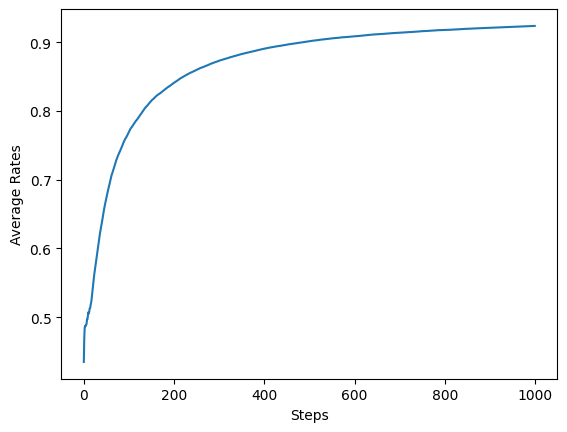

In [13]:
# 그래프 그리기: 단계별 승률
plt.ylabel('Average Rates')
plt.xlabel('Steps')
plt.plot(avg_rates)
plt.show()

In [15]:
# 정상 문제 슬롯머신(Bandit) 구현
class Bandit:
  def __init__(self, arms=10):
    self.rates = np.random.rand(arms)

  def play(self, arm):
    rate = self.rates[arm]
    if rate > np.random.rand():
      return 1
    else:
      return 0

In [16]:
# 정상 문제 에이전트 구현(엡실론-탐욕 정책 활용)
class Agent:
  def __init__(self, epsilon, action_size=10):
    self.epsilon = epsilon
    self.Qs = np.zeros(action_size)
    self.ns = np.zeros(action_size)

  def update(self, action, reward):
    self.ns[action] += 1
    self.Qs[action] += (reward - self.Qs[action]) / self.ns[action]

  def get_action(self):
    if np.random.rand() < self.epsilon:
      return np.random.randint(0, len(self.Qs))
    else:
      return np.argmax(self.Qs)

In [17]:
runs = 200
steps = 1000
epsilon = 0.1
stat_all_rates = np.zeros((runs, steps))  # (200, 1000) 형상 배엻

for run in range(runs):
  bandit = Bandit()
  agent = Agent(epsilon)
  total_reward = 0
  rates = []

  for step in range(steps):
    action = agent.get_action()
    reward = bandit.play(action)
    agent.update(action, reward)
    total_reward += reward
    rates.append(total_reward / (step + 1))

  stat_all_rates[run] = rates  # 보상 결과 기록

state_avg_rates = np.average(stat_all_rates, axis=0)  # 각 단계의 평균 저장

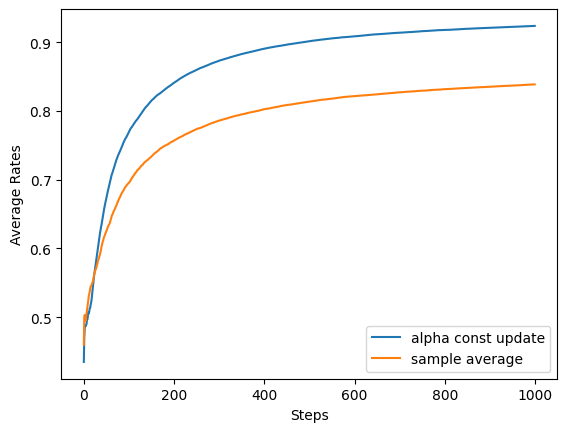

In [19]:
# 그래프 그리기: 표본 평균과 고정값 알파에 의한 갱신 비교
plt.ylabel('Average Rates')
plt.xlabel('Steps')
plt.plot(avg_rates, label='alpha const update')
plt.plot(state_avg_rates, label='sample average')
plt.legend()
plt.show()